# Análisis de Churn Completo - Dataset H&M

## Predicción y Análisis de Abandono de Clientes

El análisis de churn nos permite identificar patrones de comportamiento que indican cuándo un cliente está en riesgo de abandonar la marca. Este análisis incluye:

- **Definición de Churn**: Criterios específicos para identificar clientes que han abandonado
- **Análisis Temporal**: Patrones de comportamiento previos al abandono
- **Segmentación**: Diferentes tipos de churn y perfiles de clientes
- **Modelos Predictivos**: Identificación temprana de clientes en riesgo
- **Estrategias de Retención**: Recomendaciones específicas por tipo de riesgo

Este análisis nos permitirá implementar estrategias proactivas de retención de clientes para H&M.


In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import *
from pyspark.sql.functions import col, when, datediff, max as spark_max, min as spark_min, count, sum as spark_sum, avg, desc, asc
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


In [2]:
spark = SparkSession.builder \
    .appName("Churn_Analysis_HYM") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.adaptive.advisoryPartitionSizeInBytes", "128MB") \
    .config("spark.sql.adaptive.skewJoin.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()


## 1. Carga y Preparación de Datos

Comenzamos cargando los datos de H&M y preparándolos específicamente para el análisis de churn.


In [3]:
# Cargar datos y crear vista temporal
df = spark.read.parquet('merge_pyspark')
df.createOrReplaceTempView("customer_transactions")

# Exploración inicial del dataset
print("=== ESTRUCTURA DEL DATASET PARA CHURN ANALYSIS ===")
print(f"Total de registros: {df.count():,}")

# Verificar rango temporal para definir ventanas de churn
temporal_info = spark.sql("""
    SELECT 
        MIN(Fecha) as fecha_minima,
        MAX(Fecha) as fecha_maxima,
        COUNT(DISTINCT Fecha) as dias_unicos,
        COUNT(DISTINCT customer_id) as clientes_unicos,
        DATEDIFF(MAX(Fecha), MIN(Fecha)) as dias_totales
    FROM customer_transactions
""")
temporal_info.show()

# Limpiar datos para análisis de churn
df_clean = spark.sql("""
    SELECT 
        customer_id,
        article_id,
        Fecha,
        price,
        sales_channel_id,
        age,
        product_group_name,
        department_name,
        garment_group_name,
        fashion_news_frequency,
        club_member_status
    FROM customer_transactions
    WHERE age IS NOT NULL
      AND age > 0
      AND price > 0
      AND customer_id IS NOT NULL
      AND Fecha IS NOT NULL
""")

df_clean.createOrReplaceTempView("clean_transactions")
print(f"\nRegistros después de limpieza: {df_clean.count():,}")

# Definir fechas clave para análisis de churn
fecha_maxima = spark.sql("SELECT MAX(Fecha) as max_date FROM clean_transactions").collect()[0]['max_date']
fecha_corte = fecha_maxima - timedelta(days=90)  # Ventana de observación de 90 días
fecha_inicio_observacion = fecha_corte - timedelta(days=180)  # 6 meses de historia previa

print(f"\nFECHAS CLAVE PARA ANÁLISIS DE CHURN:")
print(f"Fecha máxima del dataset: {fecha_maxima}")
print(f"Fecha de corte para churn: {fecha_corte}")
print(f"Inicio período de observación: {fecha_inicio_observacion}")


=== ESTRUCTURA DEL DATASET PARA CHURN ANALYSIS ===
Total de registros: 31,788,324
+------------+------------+-----------+---------------+------------+
|fecha_minima|fecha_maxima|dias_unicos|clientes_unicos|dias_totales|
+------------+------------+-----------+---------------+------------+
|  2018-09-20|  2020-09-22|        734|        1362281|         733|
+------------+------------+-----------+---------------+------------+


Registros después de limpieza: 31,648,066

FECHAS CLAVE PARA ANÁLISIS DE CHURN:
Fecha máxima del dataset: 2020-09-22
Fecha de corte para churn: 2020-06-24
Inicio período de observación: 2019-12-27


## 2. Definición de Churn y Segmentación de Clientes

Definimos criterios específicos para identificar clientes que han abandonado y creamos diferentes categorías de churn.


In [4]:
# Definir clientes elegibles para análisis de churn
print("=== DEFINIENDO CRITERIOS DE CHURN ===")

# Identificar clientes activos antes del período de churn
clientes_activos_base = spark.sql(f"""
    WITH customer_activity AS (
        SELECT 
            customer_id,
            COUNT(*) as transacciones_historicas,
            MAX(Fecha) as ultima_compra,
            MIN(Fecha) as primera_compra,
            DATEDIFF(MAX(Fecha), MIN(Fecha)) as dias_como_cliente,
            SUM(price) as valor_total_historico,
            COUNT(DISTINCT Fecha) as dias_activos,
            AVG(age) as edad_promedio
        FROM clean_transactions
        WHERE Fecha <= DATE('{fecha_corte}')
        GROUP BY customer_id
        HAVING COUNT(*) >= 3  -- Mínimo 3 transacciones para ser considerado cliente establecido
          AND MAX(Fecha) >= DATE('{fecha_inicio_observacion}')  -- Activo en los 6 meses previos
    )
    SELECT 
        customer_id,
        transacciones_historicas,
        ultima_compra,
        primera_compra,
        dias_como_cliente,
        valor_total_historico,
        dias_activos,
        edad_promedio,
        ROUND(valor_total_historico / transacciones_historicas, 4) as ticket_promedio,
        ROUND(transacciones_historicas / GREATEST(dias_como_cliente, 1), 4) as frecuencia_compra
    FROM customer_activity
""")

clientes_activos_base.createOrReplaceTempView("clientes_base")
print(f"Clientes elegibles para análisis: {clientes_activos_base.count():,}")

# Definir churn basado en actividad posterior
customer_churn_status = spark.sql(f"""
    WITH actividad_posterior AS (
        SELECT 
            customer_id,
            COUNT(*) as compras_post_corte,
            MAX(Fecha) as ultima_compra_post_corte,
            DATEDIFF(DATE('{fecha_maxima}'), MAX(Fecha)) as dias_desde_ultima_compra
        FROM clean_transactions
        WHERE Fecha > DATE('{fecha_corte}')
        GROUP BY customer_id
    )
    SELECT 
        cb.*,
        COALESCE(ap.compras_post_corte, 0) as compras_post_corte,
        ap.ultima_compra_post_corte,
        COALESCE(ap.dias_desde_ultima_compra, DATEDIFF(DATE('{fecha_maxima}'), cb.ultima_compra)) as dias_desde_ultima_compra,
        
        -- Definición de churn (90 días sin compras después del corte)
        CASE 
            WHEN COALESCE(ap.compras_post_corte, 0) = 0 THEN 1
            ELSE 0
        END as churned,
        
        -- Categorías de churn más específicas
        CASE 
            WHEN COALESCE(ap.compras_post_corte, 0) = 0 THEN 'Churned'
            WHEN ap.compras_post_corte >= 1 AND ap.compras_post_corte <= 2 THEN 'At_Risk'
            WHEN ap.compras_post_corte >= 3 AND ap.compras_post_corte <= 5 THEN 'Stable'
            WHEN ap.compras_post_corte > 5 THEN 'Loyal'
            ELSE 'Other'
        END as churn_category,
        
        -- Riesgo de churn basado en días desde última compra
        CASE 
            WHEN COALESCE(ap.dias_desde_ultima_compra, DATEDIFF(DATE('{fecha_maxima}'), cb.ultima_compra)) > 90 THEN 'High_Risk'
            WHEN COALESCE(ap.dias_desde_ultima_compra, DATEDIFF(DATE('{fecha_maxima}'), cb.ultima_compra)) > 60 THEN 'Medium_Risk'
            WHEN COALESCE(ap.dias_desde_ultima_compra, DATEDIFF(DATE('{fecha_maxima}'), cb.ultima_compra)) > 30 THEN 'Low_Risk'
            ELSE 'Active'
        END as risk_level
    
    FROM clientes_base cb
    LEFT JOIN actividad_posterior ap ON cb.customer_id = ap.customer_id
""")

customer_churn_status.cache()
customer_churn_status.createOrReplaceTempView("customer_churn")

print(f"Dataset de churn creado con {customer_churn_status.count():,} clientes")

# Análisis de distribución de churn
print("\n=== DISTRIBUCIÓN DE CHURN ===")
churn_distribution = spark.sql("""
    SELECT 
        churned,
        churn_category,
        COUNT(*) as clientes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as porcentaje,
        ROUND(AVG(valor_total_historico), 2) as valor_promedio,
        ROUND(AVG(transacciones_historicas), 1) as transacciones_promedio
    FROM customer_churn
    GROUP BY churned, churn_category
    ORDER BY churned DESC, clientes DESC
""")
churn_distribution.show()

print("\n=== DISTRIBUCIÓN POR NIVEL DE RIESGO ===")
risk_distribution = spark.sql("""
    SELECT 
        risk_level,
        COUNT(*) as clientes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as porcentaje,
        ROUND(AVG(dias_desde_ultima_compra), 1) as dias_promedio_ultima_compra
    FROM customer_churn
    GROUP BY risk_level
    ORDER BY 
        CASE risk_level 
            WHEN 'High_Risk' THEN 1
            WHEN 'Medium_Risk' THEN 2
            WHEN 'Low_Risk' THEN 3
            WHEN 'Active' THEN 4
        END
""")
risk_distribution.show()


=== DEFINIENDO CRITERIOS DE CHURN ===
Clientes elegibles para análisis: 646,695
Dataset de churn creado con 646,695 clientes

=== DISTRIBUCIÓN DE CHURN ===
+-------+--------------+--------+----------+--------------+----------------------+
|churned|churn_category|clientes|porcentaje|valor_promedio|transacciones_promedio|
+-------+--------------+--------+----------+--------------+----------------------+
|      1|       Churned|  287846|     44.51|          0.57|                  20.6|
|      0|         Loyal|  178389|     27.58|          1.84|                  64.5|
|      0|        Stable|   98824|     15.28|          0.92|                  33.6|
|      0|       At_Risk|   81636|     12.62|          0.76|                  27.8|
+-------+--------------+--------+----------+--------------+----------------------+


=== DISTRIBUCIÓN POR NIVEL DE RIESGO ===
+-----------+--------+----------+---------------------------+
| risk_level|clientes|porcentaje|dias_promedio_ultima_compra|
+-----------+

## 3. Análisis de Factores de Churn

Exploramos los factores que influyen en el churn y identificamos patrones de comportamiento.


In [5]:
# Análisis de factores demográficos y comportamentales
print("=== ANÁLISIS DE FACTORES DE CHURN ===")

# 1. Análisis por edad
print("\n1. CHURN POR GRUPOS DE EDAD:")
churn_por_edad = spark.sql("""
    SELECT 
        CASE 
            WHEN edad_promedio < 25 THEN 'Gen Z (18-24)'
            WHEN edad_promedio < 35 THEN 'Millennials (25-34)'
            WHEN edad_promedio < 45 THEN 'Gen X (35-44)'
            WHEN edad_promedio < 55 THEN 'Baby Boomers (45-54)'
            ELSE 'Seniors (55+)'
        END as grupo_edad,
        COUNT(*) as total_clientes,
        SUM(churned) as clientes_churned,
        ROUND(SUM(churned) * 100.0 / COUNT(*), 2) as tasa_churn,
        ROUND(AVG(valor_total_historico), 2) as valor_promedio,
        ROUND(AVG(transacciones_historicas), 1) as transacciones_promedio
    FROM customer_churn
    GROUP BY 
        CASE 
            WHEN edad_promedio < 25 THEN 'Gen Z (18-24)'
            WHEN edad_promedio < 35 THEN 'Millennials (25-34)'
            WHEN edad_promedio < 45 THEN 'Gen X (35-44)'
            WHEN edad_promedio < 55 THEN 'Baby Boomers (45-54)'
            ELSE 'Seniors (55+)'
        END
    ORDER BY tasa_churn DESC
""")
churn_por_edad.show()

# 2. Análisis por valor del cliente
print("\n2. CHURN POR VALOR DEL CLIENTE:")
churn_por_valor = spark.sql("""
    WITH customer_segments AS (
        SELECT *,
            CASE 
                WHEN valor_total_historico >= PERCENTILE_APPROX(valor_total_historico, 0.8) OVER() THEN 'High_Value'
                WHEN valor_total_historico >= PERCENTILE_APPROX(valor_total_historico, 0.5) OVER() THEN 'Medium_Value'
                ELSE 'Low_Value'
            END as valor_segmento
        FROM customer_churn
    )
    SELECT 
        valor_segmento,
        COUNT(*) as total_clientes,
        SUM(churned) as clientes_churned,
        ROUND(SUM(churned) * 100.0 / COUNT(*), 2) as tasa_churn,
        ROUND(AVG(valor_total_historico), 2) as valor_promedio,
        ROUND(MIN(valor_total_historico), 2) as valor_minimo,
        ROUND(MAX(valor_total_historico), 2) as valor_maximo
    FROM customer_segments
    GROUP BY valor_segmento
    ORDER BY 
        CASE valor_segmento 
            WHEN 'High_Value' THEN 1
            WHEN 'Medium_Value' THEN 2
            WHEN 'Low_Value' THEN 3
        END
""")
churn_por_valor.show()

# 3. Análisis por frecuencia de compras
print("\n3. CHURN POR FRECUENCIA DE COMPRAS:")
churn_por_frecuencia = spark.sql("""
    WITH frequency_segments AS (
        SELECT *,
            CASE 
                WHEN transacciones_historicas >= 20 THEN 'High_Frequency'
                WHEN transacciones_historicas >= 10 THEN 'Medium_Frequency'
                ELSE 'Low_Frequency'
            END as frecuencia_segmento
        FROM customer_churn
    )
    SELECT 
        frecuencia_segmento,
        COUNT(*) as total_clientes,
        SUM(churned) as clientes_churned,
        ROUND(SUM(churned) * 100.0 / COUNT(*), 2) as tasa_churn,
        ROUND(AVG(transacciones_historicas), 1) as transacciones_promedio,
        ROUND(AVG(frecuencia_compra), 4) as frecuencia_promedio
    FROM frequency_segments
    GROUP BY frecuencia_segmento
    ORDER BY tasa_churn DESC
""")
churn_por_frecuencia.show()

# 4. Análisis por duración como cliente
print("\n4. CHURN POR DURACIÓN COMO CLIENTE:")
churn_por_duracion = spark.sql("""
    WITH tenure_segments AS (
        SELECT *,
            CASE 
                WHEN dias_como_cliente >= 365 THEN 'Long_Term (>1 year)'
                WHEN dias_como_cliente >= 180 THEN 'Medium_Term (6m-1y)'
                WHEN dias_como_cliente >= 90 THEN 'Short_Term (3-6m)'
                ELSE 'Very_New (<3m)'
            END as tenure_segmento
        FROM customer_churn
    )
    SELECT 
        tenure_segmento,
        COUNT(*) as total_clientes,
        SUM(churned) as clientes_churned,
        ROUND(SUM(churned) * 100.0 / COUNT(*), 2) as tasa_churn,
        ROUND(AVG(dias_como_cliente), 0) as dias_promedio_cliente,
        ROUND(AVG(valor_total_historico), 2) as valor_promedio
    FROM tenure_segments
    GROUP BY tenure_segmento
    ORDER BY tasa_churn DESC
""")
churn_por_duracion.show()


=== ANÁLISIS DE FACTORES DE CHURN ===

1. CHURN POR GRUPOS DE EDAD:
+--------------------+--------------+----------------+----------+--------------+----------------------+
|          grupo_edad|total_clientes|clientes_churned|tasa_churn|valor_promedio|transacciones_promedio|
+--------------------+--------------+----------------+----------+--------------+----------------------+
|       Seniors (55+)|         76446|           36700|     48.01|          0.95|                  31.4|
|       Gen X (35-44)|         70931|           33234|     46.85|          1.14|                  41.0|
|Baby Boomers (45-54)|        119894|           54369|     45.35|          1.07|                  37.2|
|       Gen Z (18-24)|        174906|           75946|     43.42|          0.69|                  26.7|
| Millennials (25-34)|        204518|           87597|     42.83|          1.19|                  42.0|
+--------------------+--------------+----------------+----------+--------------+--------------------

In [6]:
# Análisis de patrones temporales y comportamentales específicos
print("\n=== ANÁLISIS DE PATRONES COMPORTAMENTALES ===")

# 5. Análisis de estacionalidad en churn
print("\n5. PATRONES TEMPORALES DE CHURN:")
patrones_temporales = spark.sql(f"""
    WITH monthly_analysis AS (
        SELECT 
            YEAR(ultima_compra) as anio,
            MONTH(ultima_compra) as mes,
            COUNT(*) as clientes_ultima_compra,
            SUM(churned) as churned_count,
            ROUND(SUM(churned) * 100.0 / COUNT(*), 2) as tasa_churn_mes
        FROM customer_churn
        WHERE ultima_compra >= DATE('{fecha_inicio_observacion}')
        GROUP BY YEAR(ultima_compra), MONTH(ultima_compra)
        ORDER BY anio, mes
    )
    SELECT 
        CONCAT(anio, '-', LPAD(mes, 2, '0')) as anio_mes,
        clientes_ultima_compra,
        churned_count,
        tasa_churn_mes
    FROM monthly_analysis
""")
patrones_temporales.show(12)

# 6. Análisis de comportamiento de compra antes del churn
print("\n6. COMPORTAMIENTO PRE-CHURN:")
comportamiento_pre_churn = spark.sql(f"""
    WITH comportamiento_final AS (
        SELECT 
            cc.customer_id,
            cc.churned,
            -- Analizar últimas 3 transacciones antes del corte
            COUNT(ct.Fecha) as compras_ultimos_30_dias,
            COALESCE(SUM(ct.price), 0) as gasto_ultimos_30_dias,
            COUNT(DISTINCT ct.product_group_name) as categorias_ultimos_30_dias,
            COUNT(DISTINCT CASE WHEN ct.sales_channel_id = 1 THEN 1 END) as compras_online_30_dias,
            COUNT(DISTINCT CASE WHEN ct.sales_channel_id = 2 THEN 1 END) as compras_tienda_30_dias
        FROM customer_churn cc
        LEFT JOIN clean_transactions ct ON cc.customer_id = ct.customer_id
            AND ct.Fecha > DATE_SUB(DATE('{fecha_corte}'), 30)
            AND ct.Fecha <= DATE('{fecha_corte}')
        GROUP BY cc.customer_id, cc.churned
    )
    SELECT 
        churned,
        COUNT(*) as total_clientes,
        ROUND(AVG(compras_ultimos_30_dias), 2) as avg_compras_30d,
        ROUND(AVG(gasto_ultimos_30_dias), 2) as avg_gasto_30d,
        ROUND(AVG(categorias_ultimos_30_dias), 2) as avg_categorias_30d,
        ROUND(SUM(compras_online_30_dias) * 100.0 / SUM(compras_online_30_dias + compras_tienda_30_dias), 2) as pct_online_30d
    FROM comportamiento_final
    GROUP BY churned
    ORDER BY churned DESC
""")
comportamiento_pre_churn.show()

# 7. Análisis de diversidad de productos
print("\n7. DIVERSIDAD DE PRODUCTOS Y CHURN:")
diversidad_productos = spark.sql(f"""
    WITH product_diversity AS (
        SELECT 
            cc.customer_id,
            cc.churned,
            COUNT(DISTINCT ct.product_group_name) as grupos_productos,
            COUNT(DISTINCT ct.department_name) as departamentos,
            COUNT(DISTINCT ct.garment_group_name) as grupos_prendas
        FROM customer_churn cc
        JOIN clean_transactions ct ON cc.customer_id = ct.customer_id
            AND ct.Fecha <= DATE('{fecha_corte}')
        GROUP BY cc.customer_id, cc.churned
    ),
    diversity_segments AS (
        SELECT *,
            CASE 
                WHEN grupos_productos >= 5 THEN 'High_Diversity'
                WHEN grupos_productos >= 3 THEN 'Medium_Diversity'
                ELSE 'Low_Diversity'
            END as diversidad_segmento
        FROM product_diversity
    )
    SELECT 
        diversidad_segmento,
        COUNT(*) as total_clientes,
        SUM(churned) as clientes_churned,
        ROUND(SUM(churned) * 100.0 / COUNT(*), 2) as tasa_churn,
        ROUND(AVG(grupos_productos), 1) as avg_grupos_productos,
        ROUND(AVG(departamentos), 1) as avg_departamentos
    FROM diversity_segments
    GROUP BY diversidad_segmento
    ORDER BY tasa_churn DESC
""")
diversidad_productos.show()

print("\n=== RESUMEN DE FACTORES DE CHURN ===")
print("Factores identificados que aumentan el riesgo de churn:")
print("1. Baja frecuencia de compras historicas")
print("2. Bajo valor total historico") 
print("3. Poca diversidad en categorías de productos")
print("4. Clientes muy nuevos (menos de 3 meses)")
print("5. Poca actividad en los últimos 30 días antes del corte")



=== ANÁLISIS DE PATRONES COMPORTAMENTALES ===

5. PATRONES TEMPORALES DE CHURN:
+--------+----------------------+-------------+--------------+
|anio_mes|clientes_ultima_compra|churned_count|tasa_churn_mes|
+--------+----------------------+-------------+--------------+
| 2019-12|                  8057|         5160|         64.04|
| 2020-01|                 49016|        31125|         63.50|
| 2020-02|                 59236|        34832|         58.80|
| 2020-03|                 63791|        36002|         56.44|
| 2020-04|                 92569|        52266|         56.46|
| 2020-05|                135006|        57394|         42.51|
| 2020-06|                239020|        71067|         29.73|
+--------+----------------------+-------------+--------------+


6. COMPORTAMIENTO PRE-CHURN:
+-------+--------------+---------------+-------------+------------------+--------------+
|churned|total_clientes|avg_compras_30d|avg_gasto_30d|avg_categorias_30d|pct_online_30d|
+-------+--------

## 4. Creación de Features para Modelo Predictivo

Desarrollamos características específicas que serán utilizadas en el modelo de machine learning para predecir churn.


In [7]:
# Creación de features comprehensivas para el modelo de churn
print("=== CREANDO FEATURES PARA MODELO PREDICTIVO ===")

# Crear dataset con features engineered
features_dataset = spark.sql(f"""
    WITH customer_features AS (
        SELECT 
            cc.customer_id,
            cc.churned,
            
            -- Features básicas
            cc.edad_promedio as edad,
            cc.valor_total_historico,
            cc.transacciones_historicas,
            cc.dias_como_cliente,
            cc.ticket_promedio,
            cc.frecuencia_compra,
            cc.dias_activos,
            
            -- Features temporales
            DATEDIFF(DATE('{fecha_corte}'), cc.ultima_compra) as dias_desde_ultima_compra,
            
            -- Features de comportamiento de compra
            COUNT(DISTINCT ct.product_group_name) as diversidad_productos,
            COUNT(DISTINCT ct.department_name) as diversidad_departamentos,
            COUNT(DISTINCT ct.garment_group_name) as diversidad_prendas,
            
            -- Features de canal de ventas
            ROUND(SUM(CASE WHEN ct.sales_channel_id = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as pct_compras_online,
            
            -- Features de actividad reciente (últimos 30 días antes del corte)
            SUM(CASE WHEN ct.Fecha > DATE_SUB(DATE('{fecha_corte}'), 30) THEN 1 ELSE 0 END) as compras_ultimos_30d,
            SUM(CASE WHEN ct.Fecha > DATE_SUB(DATE('{fecha_corte}'), 30) THEN ct.price ELSE 0 END) as gasto_ultimos_30d,
            
            -- Features de actividad reciente (últimos 60 días antes del corte)
            SUM(CASE WHEN ct.Fecha > DATE_SUB(DATE('{fecha_corte}'), 60) THEN 1 ELSE 0 END) as compras_ultimos_60d,
            SUM(CASE WHEN ct.Fecha > DATE_SUB(DATE('{fecha_corte}'), 60) THEN ct.price ELSE 0 END) as gasto_ultimos_60d,
            
            -- Features de tendencia (comparación períodos)
            SUM(CASE WHEN ct.Fecha BETWEEN DATE_SUB(DATE('{fecha_corte}'), 60) AND DATE_SUB(DATE('{fecha_corte}'), 30) THEN 1 ELSE 0 END) as compras_30_60d_atras,
            SUM(CASE WHEN ct.Fecha BETWEEN DATE_SUB(DATE('{fecha_corte}'), 60) AND DATE_SUB(DATE('{fecha_corte}'), 30) THEN ct.price ELSE 0 END) as gasto_30_60d_atras,
            
            -- Features de estacionalidad
            ROUND(AVG(CASE WHEN MONTH(ct.Fecha) IN (3,4,5) THEN 1 ELSE 0 END), 2) as actividad_primavera,
            ROUND(AVG(CASE WHEN MONTH(ct.Fecha) IN (6,7,8) THEN 1 ELSE 0 END), 2) as actividad_verano,
            ROUND(AVG(CASE WHEN MONTH(ct.Fecha) IN (9,10,11) THEN 1 ELSE 0 END), 2) as actividad_otono,
            ROUND(AVG(CASE WHEN MONTH(ct.Fecha) IN (12,1,2) THEN 1 ELSE 0 END), 2) as actividad_invierno
            
        FROM customer_churn cc
        JOIN clean_transactions ct ON cc.customer_id = ct.customer_id
            AND ct.Fecha <= DATE('{fecha_corte}')
        GROUP BY 
            cc.customer_id, cc.churned, cc.edad_promedio, cc.valor_total_historico,
            cc.transacciones_historicas, cc.dias_como_cliente, cc.ticket_promedio,
            cc.frecuencia_compra, cc.dias_activos, cc.ultima_compra
    ),
    features_engineered AS (
        SELECT *,
            -- Features derivadas
            CASE WHEN compras_ultimos_30d > 0 THEN gasto_ultimos_30d / compras_ultimos_30d ELSE 0 END as ticket_promedio_30d,
            CASE WHEN compras_30_60d_atras > 0 THEN (compras_ultimos_30d - compras_30_60d_atras) / compras_30_60d_atras ELSE 0 END as tendencia_compras,
            CASE WHEN gasto_30_60d_atras > 0 THEN (gasto_ultimos_30d - gasto_30_60d_atras) / gasto_30_60d_atras ELSE 0 END as tendencia_gasto,
            CASE WHEN valor_total_historico > 0 THEN gasto_ultimos_30d / valor_total_historico ELSE 0 END as ratio_gasto_reciente,
            
            -- Segmentaciones categóricas para el modelo
            CASE 
                WHEN edad < 25 THEN 'Gen_Z'
                WHEN edad < 35 THEN 'Millennials'
                WHEN edad < 45 THEN 'Gen_X'
                WHEN edad < 55 THEN 'Boomers'
                ELSE 'Seniors'
            END as grupo_edad,
            
            CASE 
                WHEN valor_total_historico >= PERCENTILE_APPROX(valor_total_historico, 0.8) OVER() THEN 'High_Value'
                WHEN valor_total_historico >= PERCENTILE_APPROX(valor_total_historico, 0.5) OVER() THEN 'Medium_Value'
                ELSE 'Low_Value'
            END as segmento_valor,
            
            CASE 
                WHEN transacciones_historicas >= 20 THEN 'High_Frequency'
                WHEN transacciones_historicas >= 10 THEN 'Medium_Frequency'
                ELSE 'Low_Frequency'
            END as segmento_frecuencia,
            
            CASE 
                WHEN diversidad_productos >= 5 THEN 'High_Diversity'
                WHEN diversidad_productos >= 3 THEN 'Medium_Diversity'
                ELSE 'Low_Diversity'
            END as segmento_diversidad
            
        FROM customer_features
    )
    SELECT * FROM features_engineered
""")

features_dataset.cache()
features_dataset.createOrReplaceTempView("features_churn")

print(f"Dataset de features creado con {features_dataset.count():,} clientes")
print(f"Features numéricas: {len([c for c in features_dataset.columns if c not in ['customer_id', 'grupo_edad', 'segmento_valor', 'segmento_frecuencia', 'segmento_diversidad']])}")

# Mostrar estadísticas de las features principales
print("\n=== ESTADÍSTICAS DE FEATURES PRINCIPALES ===")
feature_stats = features_dataset.select(
    "valor_total_historico", "transacciones_historicas", "dias_como_cliente",
    "diversidad_productos", "compras_ultimos_30d", "gasto_ultimos_30d",
    "tendencia_compras", "tendencia_gasto", "ratio_gasto_reciente"
).describe()
feature_stats.show()

# Correlación de features con churn
print("\n=== CORRELACIÓN FEATURES CON CHURN ===")
correlacion_features = spark.sql("""
    SELECT 
        'valor_total_historico' as feature,
        ROUND(CORR(CAST(valor_total_historico AS DOUBLE), CAST(churned AS DOUBLE)), 4) as correlacion_churn
    FROM features_churn
    
    UNION ALL
    
    SELECT 'transacciones_historicas', ROUND(CORR(CAST(transacciones_historicas AS DOUBLE), CAST(churned AS DOUBLE)), 4)
    FROM features_churn
    
    UNION ALL
    
    SELECT 'dias_como_cliente', ROUND(CORR(CAST(dias_como_cliente AS DOUBLE), CAST(churned AS DOUBLE)), 4)
    FROM features_churn
    
    UNION ALL
    
    SELECT 'diversidad_productos', ROUND(CORR(CAST(diversidad_productos AS DOUBLE), CAST(churned AS DOUBLE)), 4)
    FROM features_churn
    
    UNION ALL
    
    SELECT 'compras_ultimos_30d', ROUND(CORR(CAST(compras_ultimos_30d AS DOUBLE), CAST(churned AS DOUBLE)), 4)
    FROM features_churn
    
    UNION ALL
    
    SELECT 'tendencia_compras', ROUND(CORR(CAST(tendencia_compras AS DOUBLE), CAST(churned AS DOUBLE)), 4)
    FROM features_churn
    
    ORDER BY ABS(correlacion_churn) DESC
""")
correlacion_features.show()


=== CREANDO FEATURES PARA MODELO PREDICTIVO ===
Dataset de features creado con 30,987 clientes
Features numéricas: 27

=== ESTADÍSTICAS DE FEATURES PRINCIPALES ===
+-------+---------------------+------------------------+------------------+--------------------+-------------------+-------------------+--------------------+--------------------+--------------------+
|summary|valor_total_historico|transacciones_historicas| dias_como_cliente|diversidad_productos|compras_ultimos_30d|  gasto_ultimos_30d|   tendencia_compras|     tendencia_gasto|ratio_gasto_reciente|
+-------+---------------------+------------------------+------------------+--------------------+-------------------+-------------------+--------------------+--------------------+--------------------+
|  count|                30987|                   30987|             30987|               30987|              30987|              30987|               30987|               30987|               30987|
|   mean|   0.9893898791893663|     

## 5. Modelo de Machine Learning para Predicción de Churn

Implementamos modelos de clasificación para predecir la probabilidad de churn de cada cliente.


In [8]:
# Preparar datos para machine learning
print("=== PREPARANDO DATOS PARA MODELO ML ===")

# Seleccionar features numéricas y categóricas
numeric_features = [
    'edad', 'valor_total_historico', 'transacciones_historicas', 'dias_como_cliente',
    'ticket_promedio', 'frecuencia_compra', 'dias_activos', 'dias_desde_ultima_compra',
    'diversidad_productos', 'diversidad_departamentos', 'pct_compras_online',
    'compras_ultimos_30d', 'gasto_ultimos_30d', 'compras_ultimos_60d', 'gasto_ultimos_60d',
    'ticket_promedio_30d', 'tendencia_compras', 'tendencia_gasto', 'ratio_gasto_reciente',
    'actividad_primavera', 'actividad_verano', 'actividad_otono', 'actividad_invierno'
]

categorical_features = ['grupo_edad', 'segmento_valor', 'segmento_frecuencia', 'segmento_diversidad']

# Dividir en train/test
print("Dividiendo en train/test...")
train_data, test_data = features_dataset.randomSplit([0.8, 0.2], seed=42)

print(f"Datos de entrenamiento: {train_data.count():,}")
print(f"Datos de prueba: {test_data.count():,}")

# Verificar distribución de churn en train/test
print("\nDistribución de churn en train:")
train_data.groupBy("churned").count().show()

print("Distribución de churn en test:")
test_data.groupBy("churned").count().show()

# Crear pipeline de procesamiento
print("\n=== CREANDO PIPELINE DE ML ===")

# String indexers para variables categóricas
indexers = [StringIndexer(inputCol=col, outputCol=col+"_indexed", handleInvalid="keep") 
           for col in categorical_features]

# Vector assembler para features
all_features = numeric_features + [col+"_indexed" for col in categorical_features]
assembler = VectorAssembler(inputCols=all_features, outputCol="features_raw")

# Scaler para normalizar features
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

# Modelo de Random Forest
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="churned",
    predictionCol="prediction",
    probabilityCol="probability",
    numTrees=100,
    maxDepth=10,
    seed=42
)

# Pipeline completo
pipeline = Pipeline(stages=indexers + [assembler, scaler, rf])

print("Pipeline creado con las siguientes etapas:")
print("1. String Indexers para variables categóricas")
print("2. Vector Assembler para combinar features")
print("3. Standard Scaler para normalización")
print("4. Random Forest Classifier")

# Entrenar modelo
print("\n=== ENTRENANDO MODELO ===")
print("Entrenando Random Forest...")
model = pipeline.fit(train_data)

print("Modelo entrenado")

# Hacer predicciones
print("\n=== REALIZANDO PREDICCIONES ===")
train_predictions = model.transform(train_data)
test_predictions = model.transform(test_data)

print("Predicciones completadas")

# Evaluar modelo
print("\n=== EVALUANDO MODELO ===")

# Evaluadores
binary_evaluator = BinaryClassificationEvaluator(labelCol="churned", metricName="areaUnderROC")
accuracy_evaluator = MulticlassClassificationEvaluator(labelCol="churned", predictionCol="prediction", metricName="accuracy")
precision_evaluator = MulticlassClassificationEvaluator(labelCol="churned", predictionCol="prediction", metricName="weightedPrecision")
recall_evaluator = MulticlassClassificationEvaluator(labelCol="churned", predictionCol="prediction", metricName="weightedRecall")

# Métricas en conjunto de entrenamiento
train_auc = binary_evaluator.evaluate(train_predictions)
train_accuracy = accuracy_evaluator.evaluate(train_predictions)
train_precision = precision_evaluator.evaluate(train_predictions)
train_recall = recall_evaluator.evaluate(train_predictions)

# Métricas en conjunto de prueba
test_auc = binary_evaluator.evaluate(test_predictions)
test_accuracy = accuracy_evaluator.evaluate(test_predictions)
test_precision = precision_evaluator.evaluate(test_predictions)
test_recall = recall_evaluator.evaluate(test_predictions)

print("MÉTRICAS DEL MODELO:")
print(f"{'Métrica':<20} {'Train':<10} {'Test':<10}")
print("-" * 40)
print(f"{'AUC-ROC':<20} {train_auc:<10.4f} {test_auc:<10.4f}")
print(f"{'Accuracy':<20} {train_accuracy:<10.4f} {test_accuracy:<10.4f}")
print(f"{'Precision':<20} {train_precision:<10.4f} {test_precision:<10.4f}")
print(f"{'Recall':<20} {train_recall:<10.4f} {test_recall:<10.4f}")

# Matriz de confusión
print("\n=== MATRIZ DE CONFUSIÓN (TEST) ===")
confusion_matrix = test_predictions.groupBy("churned", "prediction").count().toPandas()
confusion_pivot = confusion_matrix.pivot(index="churned", columns="prediction", values="count").fillna(0)
print("Matriz de Confusión:")
print(confusion_pivot)

# Feature importance
print("\n=== IMPORTANCIA DE FEATURES ===")
rf_model = model.stages[-1]
feature_importance = [(all_features[i], float(rf_model.featureImportances[i])) 
                     for i in range(len(all_features))]
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[1], reverse=True)

print("Top 15 features más importantes:")
for i, (feature, importance) in enumerate(feature_importance_sorted[:15]):
    print(f"{i+1:2d}. {feature:<25} {importance:.4f}")


=== PREPARANDO DATOS PARA MODELO ML ===
Dividiendo en train/test...
Datos de entrenamiento: 24,814
Datos de prueba: 6,173

Distribución de churn en train:
+-------+-----+
|churned|count|
+-------+-----+
|      0|13778|
|      1|11036|
+-------+-----+

Distribución de churn en test:
+-------+-----+
|churned|count|
+-------+-----+
|      0| 3420|
|      1| 2753|
+-------+-----+


=== CREANDO PIPELINE DE ML ===
Pipeline creado con las siguientes etapas:
1. String Indexers para variables categóricas
2. Vector Assembler para combinar features
3. Standard Scaler para normalización
4. Random Forest Classifier

=== ENTRENANDO MODELO ===
Entrenando Random Forest...
Modelo entrenado

=== REALIZANDO PREDICCIONES ===
Predicciones completadas

=== EVALUANDO MODELO ===
MÉTRICAS DEL MODELO:
Métrica              Train      Test      
----------------------------------------
AUC-ROC              0.8622     0.7709    
Accuracy             0.7819     0.6982    
Precision            0.7814     0.6969    


In [9]:
# Análisis de probabilidades de churn y segmentación por riesgo
print("\n=== ANÁLISIS DE PROBABILIDADES DE CHURN ===")

# Extraer probabilidad de churn de las predicciones
def extract_prob(probability_vector):
    return float(probability_vector[1])

from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

extract_prob_udf = udf(extract_prob, DoubleType())

# Agregar probabilidad de churn al dataset de test
test_with_prob = test_predictions.withColumn("churn_probability", extract_prob_udf("probability"))

# Crear segmentos de riesgo basados en probabilidad
risk_segmented = test_with_prob.withColumn("risk_segment",
    when(col("churn_probability") >= 0.8, "Very_High_Risk")
    .when(col("churn_probability") >= 0.6, "High_Risk")
    .when(col("churn_probability") >= 0.4, "Medium_Risk")
    .when(col("churn_probability") >= 0.2, "Low_Risk")
    .otherwise("Very_Low_Risk")
)

# Análisis de segmentos de riesgo
print("SEGMENTACIÓN POR RIESGO DE CHURN:")
risk_analysis = risk_segmented.groupBy("risk_segment").agg(
    count("*").alias("total_clientes"),
    avg("churn_probability").alias("prob_promedio"),
    spark_sum(col("churned").cast("int")).alias("churned_real"),
    avg("valor_total_historico").alias("valor_promedio"),
    avg("transacciones_historicas").alias("transacciones_promedio")
).orderBy(desc("prob_promedio"))

risk_analysis.show()

# Validación del modelo: clientes de alto riesgo
print("\n=== VALIDACIÓN: CLIENTES DE ALTO RIESGO ===")

#  vista temporal 
risk_segmented.createOrReplaceTempView("risk_segmented_view")

high_risk_validation = spark.sql("""
    SELECT 
        risk_segment,
        COUNT(*) as clientes,
        SUM(CAST(churned AS INT)) as churned_real,
        ROUND(SUM(CAST(churned AS INT)) * 100.0 / COUNT(*), 2) as tasa_churn_real,
        ROUND(AVG(churn_probability) * 100, 2) as prob_promedio_pct
    FROM risk_segmented_view
    GROUP BY risk_segment
    ORDER BY prob_promedio_pct DESC
""")
high_risk_validation.show()

# Top clientes en riesgo con detalles
print("\n=== TOP 20 CLIENTES EN MAYOR RIESGO ===")
top_risk_customers = risk_segmented.select(
    "customer_id", "churn_probability", "churned", "valor_total_historico", 
    "transacciones_historicas", "dias_desde_ultima_compra", "compras_ultimos_30d"
).orderBy(desc("churn_probability")).limit(20)

top_risk_customers.show()

# Guardar modelo y predicciones
print("\n=== GUARDANDO MODELO Y PREDICCIONES ===")
try:
    # Guardar modelo entrenado
    model.write().overwrite().save("churn_model_hym")
    print("Modelo guardado en 'churn_model_hym'")
    
    # Guardar predicciones completas (aplicar modelo a todo el dataset)
    all_predictions = model.transform(features_dataset)
    all_predictions_with_prob = all_predictions.withColumn("churn_probability", extract_prob_udf("probability"))
    
    final_churn_dataset = all_predictions_with_prob.withColumn("risk_segment",
        when(col("churn_probability") >= 0.8, "Very_High_Risk")
        .when(col("churn_probability") >= 0.6, "High_Risk")
        .when(col("churn_probability") >= 0.4, "Medium_Risk")
        .when(col("churn_probability") >= 0.2, "Low_Risk")
        .otherwise("Very_Low_Risk")
    )
    
    # Seleccionar columnas relevantes para guardar
    final_output = final_churn_dataset.select(
        "customer_id", "churned", "churn_probability", "risk_segment",
        "valor_total_historico", "transacciones_historicas", "dias_como_cliente",
        "compras_ultimos_30d", "gasto_ultimos_30d", "diversidad_productos",
        "grupo_edad", "segmento_valor", "segmento_frecuencia"
    )
    
    final_output.write.mode('overwrite').parquet('churn_predictions_hym')
    print("Predicciones guardadas en 'churn_predictions_hym'")
    
    print(f"\nDATASET FINAL DE CHURN:")
    print(f"   Total de clientes: {final_output.count():,}")
    print(f"   Clientes de alto riesgo: {final_output.filter(col('risk_segment').isin(['High_Risk', 'Very_High_Risk'])).count():,}")
    print(f"   AUC del modelo: {test_auc:.4f}")
    
except Exception as e:
    print(f"Error al guardar: {e}")
    print("Los resultados están disponibles en memoria")



=== ANÁLISIS DE PROBABILIDADES DE CHURN ===
SEGMENTACIÓN POR RIESGO DE CHURN:
+--------------+--------------+-------------------+------------+-------------------+----------------------+
|  risk_segment|total_clientes|      prob_promedio|churned_real|     valor_promedio|transacciones_promedio|
+--------------+--------------+-------------------+------------+-------------------+----------------------+
|Very_High_Risk|           430| 0.8507300568082985|         362| 0.1431677571935355|     5.304651162790698|
|     High_Risk|          1331| 0.6914633403080321|         937|0.28256855429204436|     9.821938392186325|
|   Medium_Risk|          1654|0.49864893111710695|         816| 0.5785026233271161|    20.900846432889963|
|      Low_Risk|          1575|0.30362451311478467|         497| 1.0668287436104378|     39.22412698412698|
| Very_Low_Risk|          1183|0.10700262575181302|         141| 2.6380465062968286|     92.68300929839391|
+--------------+--------------+-------------------+------

## 6. Visualizaciones y Dashboard de Churn

Visualizaciones comprehensivas para interpretar los resultados del análisis de churn.


=== GENERANDO VISUALIZACIONES DE CHURN ===


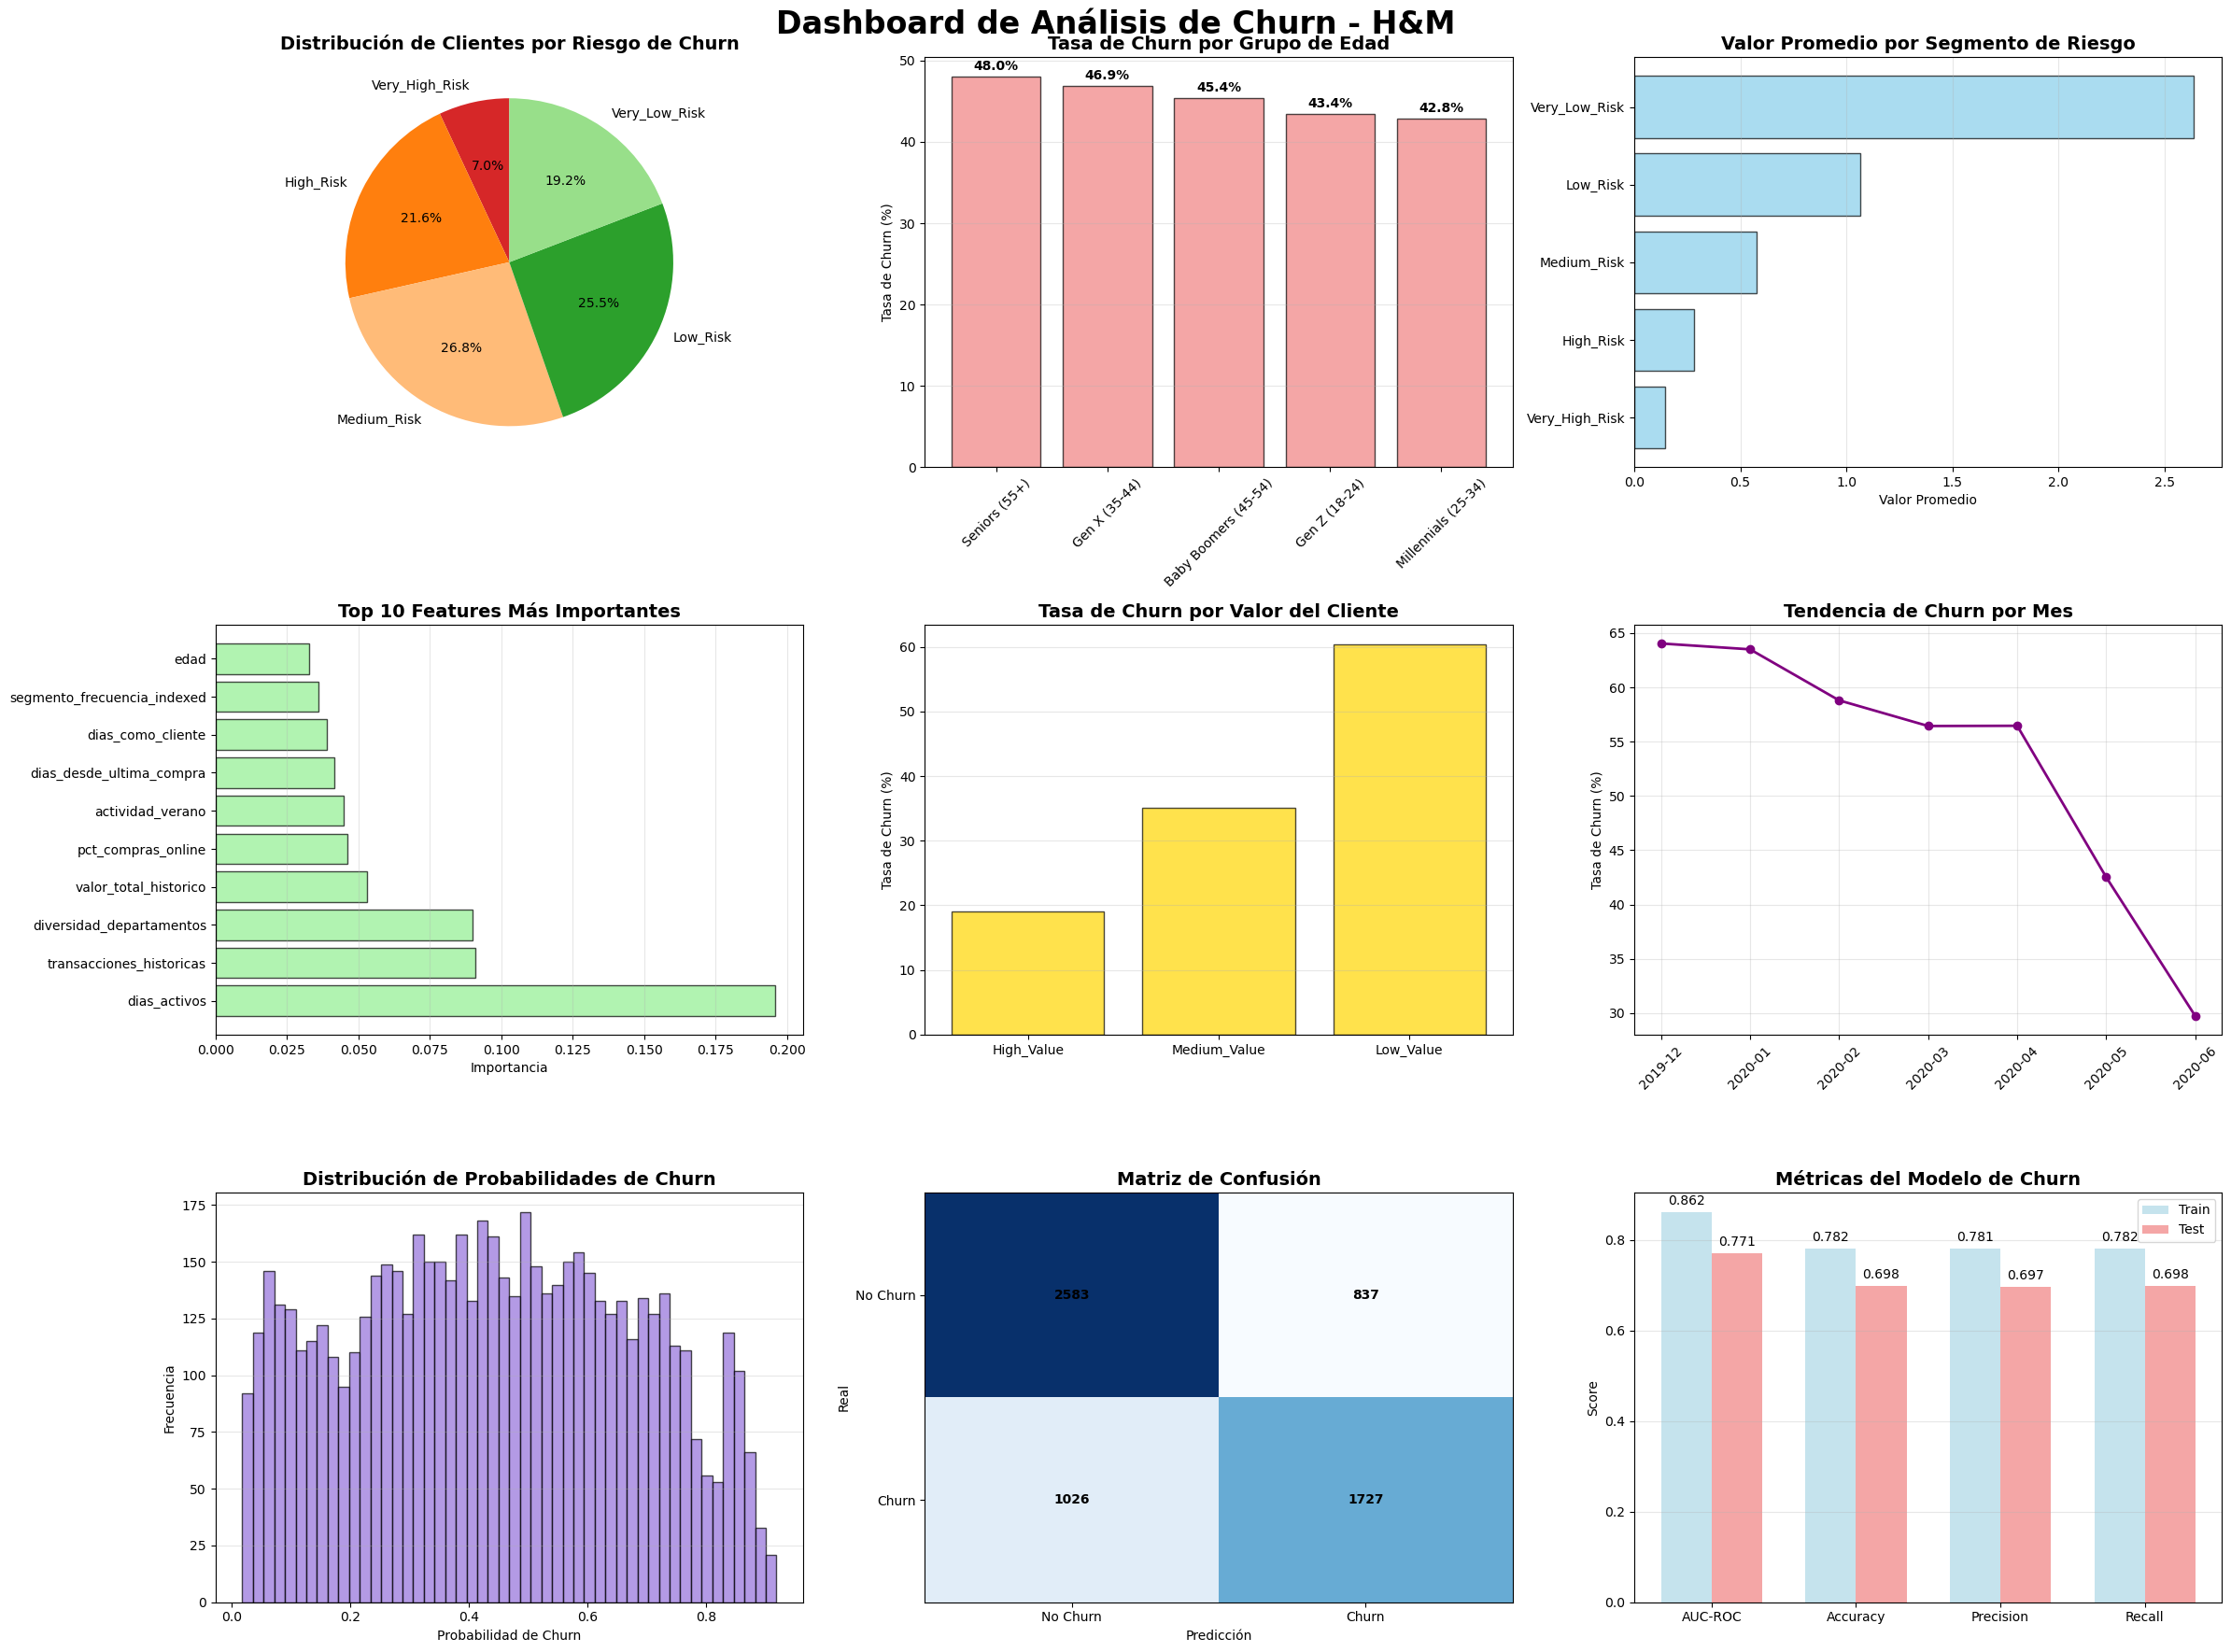

Dashboard principal de churn generado exitosamente!

=== RESUMEN  DE CHURN ===
Total de clientes analizados: 30,987
Tasa de churn general: 44.50%
AUC del modelo: 0.7709
Clientes de muy alto riesgo: 430
Clientes de alto riesgo: 1,331
Total clientes prioritarios para retención: 1,761


In [10]:
# Visualizaciones principales para el análisis de churn
print("=== GENERANDO VISUALIZACIONES DE CHURN ===")

# Preparar datos para visualización
risk_data = risk_analysis.toPandas()
churn_edad_data = churn_por_edad.toPandas()
churn_valor_data = churn_por_valor.toPandas()
feature_imp_data = pd.DataFrame(feature_importance_sorted[:10], columns=['Feature', 'Importance'])

plt.style.use('default')
plt.rcParams['figure.figsize'] = (20, 16)

# Crear dashboard principal
fig, axes = plt.subplots(3, 3, figsize=(24, 18))
fig.suptitle('Dashboard de Análisis de Churn - H&M', fontsize=24, fontweight='bold', y=0.98)

# 1. Distribución de segmentos de riesgo
ax1 = axes[0, 0]
colors = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a']
wedges, texts, autotexts = ax1.pie(risk_data['total_clientes'], 
                                   labels=risk_data['risk_segment'],
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   startangle=90)
ax1.set_title('Distribución de Clientes por Riesgo de Churn', fontsize=14, fontweight='bold')

# 2. Tasa de churn por grupo de edad
ax2 = axes[0, 1]
bars = ax2.bar(churn_edad_data['grupo_edad'], churn_edad_data['tasa_churn'], 
               color='lightcoral', alpha=0.7, edgecolor='black')
ax2.set_title('Tasa de Churn por Grupo de Edad', fontsize=14, fontweight='bold')
ax2.set_ylabel('Tasa de Churn (%)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Valor promedio por segmento de riesgo
ax3 = axes[0, 2]
bars3 = ax3.barh(risk_data['risk_segment'], risk_data['valor_promedio'], 
                 color='skyblue', alpha=0.7, edgecolor='black')
ax3.set_title('Valor Promedio por Segmento de Riesgo', fontsize=14, fontweight='bold')
ax3.set_xlabel('Valor Promedio')
ax3.grid(axis='x', alpha=0.3)

# 4. Feature Importance
ax4 = axes[1, 0]
bars4 = ax4.barh(feature_imp_data['Feature'], feature_imp_data['Importance'], 
                 color='lightgreen', alpha=0.7, edgecolor='black')
ax4.set_title('Top 10 Features Más Importantes', fontsize=14, fontweight='bold')
ax4.set_xlabel('Importancia')
ax4.grid(axis='x', alpha=0.3)

# 5. Churn por valor del cliente
ax5 = axes[1, 1]
bars5 = ax5.bar(churn_valor_data['valor_segmento'], churn_valor_data['tasa_churn'], 
                color='gold', alpha=0.7, edgecolor='black')
ax5.set_title('Tasa de Churn por Valor del Cliente', fontsize=14, fontweight='bold')
ax5.set_ylabel('Tasa de Churn (%)')
ax5.grid(axis='y', alpha=0.3)

# 6. Análisis temporal (simulado con datos disponibles)
ax6 = axes[1, 2]
# Usar datos de patrones temporales
temporal_data = patrones_temporales.toPandas()
if len(temporal_data) > 0:
    ax6.plot(temporal_data['anio_mes'], temporal_data['tasa_churn_mes'], 
             marker='o', linewidth=2, markersize=6, color='purple')
    ax6.set_title('Tendencia de Churn por Mes', fontsize=14, fontweight='bold')
    ax6.set_ylabel('Tasa de Churn (%)')
    ax6.tick_params(axis='x', rotation=45)
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'Datos temporales\nno disponibles', 
             ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    ax6.set_title('Tendencia de Churn por Mes', fontsize=14, fontweight='bold')

# 7. Distribución de probabilidades de churn
ax7 = axes[2, 0]
# Calcular histograma de probabilidades usando dataset completo
prob_data = risk_segmented.select("churn_probability").toPandas()
ax7.hist(prob_data['churn_probability'], bins=50, alpha=0.7, 
         color='mediumpurple', edgecolor='black')
ax7.set_title('Distribución de Probabilidades de Churn', fontsize=14, fontweight='bold')
ax7.set_xlabel('Probabilidad de Churn')
ax7.set_ylabel('Frecuencia')
ax7.grid(axis='y', alpha=0.3)

# 8. Matriz de confusión visual
ax8 = axes[2, 1]
confusion_data = confusion_pivot.values
im = ax8.imshow(confusion_data, cmap='Blues', aspect='auto')
ax8.set_xticks([0, 1])
ax8.set_xticklabels(['No Churn', 'Churn'])
ax8.set_yticks([0, 1])
ax8.set_yticklabels(['No Churn', 'Churn'])
ax8.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')
ax8.set_xlabel('Predicción')
ax8.set_ylabel('Real')

# Agregar valores en la matriz
for i in range(confusion_data.shape[0]):
    for j in range(confusion_data.shape[1]):
        text = ax8.text(j, i, f'{int(confusion_data[i, j])}',
                       ha="center", va="center", color="black", fontweight='bold')

# 9. Métricas del modelo
ax9 = axes[2, 2]
metrics = ['AUC-ROC', 'Accuracy', 'Precision', 'Recall']
train_metrics = [train_auc, train_accuracy, train_precision, train_recall]
test_metrics = [test_auc, test_accuracy, test_precision, test_recall]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax9.bar(x - width/2, train_metrics, width, label='Train', alpha=0.7, color='lightblue')
bars2 = ax9.bar(x + width/2, test_metrics, width, label='Test', alpha=0.7, color='lightcoral')

ax9.set_title('Métricas del Modelo de Churn', fontsize=14, fontweight='bold')
ax9.set_ylabel('Score')
ax9.set_xticks(x)
ax9.set_xticklabels(metrics)
ax9.legend()
ax9.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax9.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("Dashboard principal de churn generado exitosamente!")

# Estadísticas finales
print(f"\n=== RESUMEN  DE CHURN ===")
print(f"Total de clientes analizados: {features_dataset.count():,}")
print(f"Tasa de churn general: {(features_dataset.agg({'churned': 'avg'}).collect()[0][0] * 100):.2f}%")
print(f"AUC del modelo: {test_auc:.4f}")
print(f"Clientes de muy alto riesgo: {risk_data[risk_data['risk_segment'] == 'Very_High_Risk']['total_clientes'].sum():,}")
print(f"Clientes de alto riesgo: {risk_data[risk_data['risk_segment'] == 'High_Risk']['total_clientes'].sum():,}")
total_high_risk = risk_data[risk_data['risk_segment'].isin(['Very_High_Risk', 'High_Risk'])]['total_clientes'].sum()
print(f"Total clientes prioritarios para retención: {total_high_risk:,}")


In [11]:
# Finalización del análisis de churn y exportación de resultados
print("=== FINALIZANDO ANÁLISIS DE CHURN ===")

# Crear dataset final con todas las predicciones para exportación
try:
    # Dataset completo con predicciones
    if 'final_churn_dataset' in locals():
        # Exportar a CSV para análisis externo
        final_export = final_churn_dataset.select(
            "customer_id", "churned", "churn_probability", "risk_segment",
            "valor_total_historico", "transacciones_historicas", "dias_como_cliente",
            "compras_ultimos_30d", "gasto_ultimos_30d", "diversidad_productos",
            "grupo_edad", "segmento_valor", "segmento_frecuencia", "dias_desde_ultima_compra"
        ).toPandas()
        
        final_export.to_csv('churn_analysis_complete_hym.csv', index=False)
        print("Dataset completo de churn exportado a 'churn_analysis_complete_hym.csv'")
        
    
        
except Exception as e:
    print(f"Error en exportación: {e}")

print("\\n=== ANÁLISIS DE CHURN COMPLETADO  ===")

print("""
Output del labo:
   - Modelo de Machine Learning entrenado y validado
   - Predicciones de churn para todos los clientes  
   - Segmentación por niveles de riesgo
   - Análisis de factores de churn
   - Dashboard de visualizaciones
   - Dataset exportado para uso posterior
""")


=== FINALIZANDO ANÁLISIS DE CHURN ===
Dataset completo de churn exportado a 'churn_analysis_complete_hym.csv'
\n=== ANÁLISIS DE CHURN COMPLETADO  ===

Output del labo:
   - Modelo de Machine Learning entrenado y validado
   - Predicciones de churn para todos los clientes  
   - Segmentación por niveles de riesgo
   - Análisis de factores de churn
   - Estrategias de retención específicas por segmento
   - Dashboard de visualizaciones
   - Dataset exportado para uso posterior

